# 프로젝트 관련 내용

| 번호 | 테이블명             | 테이블 설명                   | 주요 컬럼                                               |
|------|----------------------|-------------------------------|----------------------------------------------------------|
| 1    | trial_register       | 3일체험 신청                  | 유저id, 3일체험신청일시                                  |
| 2    | trial_visit_info     | 3일체험 신청자 일자별 방문기록 | 유저id, 날짜, 지점id, 최초입실시각, 최종퇴실시각, 체류시간 |
| 3    | trial_access_log     | 3일체험 신청자 출입기록        | 유저id, 지점id, timestamp, 출입방향                      |
| 4    | trial_payment        | 3일체험 신청자 결제 여부       | 유저id, 결제여부                                         |
| 5    | site_area            | 지점별 면적                   | 지점id, 지점 면적                                        |


이번 데이터에서는 다음과 같은 오류값들이 존재합니다. 팀원 분들과 충분히 논의한 뒤 합리적이라고 생각하는 방식대로 오류값들을 처리해주세요. (추가로 발견했다면 그 점에 대해 언급해주셔도 좋아요.)
| 테이블             | 이상치 내용                                                                                                                                     | 이상치 원인                                                                                                                                                        |
|------------------|----------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| trial_register    | 1) 같은 날 2회 3일 체험을 신청한 경우<br>2) 서로 다른 날 2회 3일 체험을 신청한 경우                                                            | 1) 전산 오류로 인해 현장 매니저가 임시로 권한 부여한 케이스<br>2) 체험 신청 후 방문하지 못해 재신청한 케이스                                                       |
| trial_visit_info  | 1) `stay_time`은 결측치가 없는데 `first_enter_time` 또는 `last_leave_time`이 결측치인 경우<br>2) `stay_time`과 입·퇴실 시각이 일치하지 않는 경우 | 1) 분 단위 출입으로 인해 기록 누락 가능<br>2) 중간 퇴실/재입실로 인해 `stay_time`이 `first_enter_time`~`last_leave_time` 구간과 일치하지 않을 수 있음              |


이상치 처리 이원찬 개인적인 전처리 의견

trial_register 내용

- 같은 날 2회 3일 체험을 신청한 경우
- 서로 다른 날 2회 3일 체험을 신청한 경우
    - `drop_duplicates()` 를 적용한 뒤 `keep=first` 값으로 유지 (최초 체험은 첫 번째 순서를 부여)

trial_visit_info 내용

- `stay_time` 은 결측치가 없는데 first_enter_time 또는 last_leave_time이 결측치인 경우
- `stay_time` 과 입/퇴실 시각이 일치하지 않는 경우
    - `stay_time` 은 입/퇴실의 파생 변수로 인식
    - 머신 러닝을 진행할 시 입/퇴실 시각 컬럼은 삭제 
    - 혹은 이용 시간대가 아침/점심/저녁/야간 인지 분류하는 period 값을 새로 추가 → 이는 입/퇴실 시간이 모두 존재하는 데이터만 보존하고 나머지는 drop 처리

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
trial_register = pd.read_csv('./data/trial_register.csv')
trial_visit_info = pd.read_csv('./data/trial_visit_info.csv')
trial_access_log = pd.read_csv('./data/trial_access_log.csv')
trial_payment = pd.read_csv('./data/trial_payment.csv')
site_area = pd.read_csv('./data/site_area.csv')

In [50]:
df_lst = [trial_register, trial_visit_info, trial_access_log, trial_payment, site_area]

for df in df_lst:
    display(df.head(5))

,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3
3,2023-12-21,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,2023-12-21,1d49ba36-6c23-405b-9514-aa7f4aeceff0


,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73
3,1,2023-12-23,04:37:36.134901,16656,2023-12-23 14:49:40.302823,2023-12-23 19:27:39.406803,ba49324f-d317-4053-adf9-2b17b3f07594
4,3,2023-12-26,04:32:05.289251,16325,2023-12-26 14:57:10.220793,2023-12-26 19:34:36.971542,ba49324f-d317-4053-adf9-2b17b3f07594


,id,checkin,cdate,site_id,user_uuid
0,1719038,1,2023-07-07 07:11:55.201673,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,1716702,2,2023-07-06 15:15:58.761284,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,1719956,2,2023-07-07 14:10:41.848998,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
3,1716588,1,2023-07-06 13:09:48.758097,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
4,1719649,1,2023-07-07 10:12:42.083352,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89


,is_payment,user_uuid
0,0,2b251333-8676-4c11-a736-dcf2350f8821
1,0,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,1,4a184795-b056-4572-a874-644f68609ea3
3,0,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,0,1d49ba36-6c23-405b-9514-aa7f4aeceff0


,site_id,area_pyeong
0,1,50
1,2,100
2,3,150
3,4,100
4,5,150


In [51]:
def basic_information(df):
    print(f'data shape : {df.shape}')
    
    basic_info_df = pd.DataFrame(data=df.dtypes, columns=['dtypes'])
    basic_info_df['missing'] = df.isnull().sum().values
    basic_info_df['missing_rate (%)'] = df.isnull().sum().values / len(df) * 100
    basic_info_df['nunique'] = df.nunique().values

    # describe 통계량 (수치형/범주형 포함)
    desc_df = df.describe(include='all').transpose()

    # 수치형 항목만 해당되는 통계량 추가
    for col in ['mean', 'std', 'min', 'max']:
        if col in desc_df.columns:
            basic_info_df[col] = desc_df[col]

    # 최빈값 및 해당 최빈값의 count
    basic_info_df['mode'] = {col: df[col].mode(dropna=True).iloc[0] if not df[col].mode(dropna=True).empty else None for col in df.columns}
    basic_info_df['mode_counts'] = {col: df[col].value_counts().max() if not df[col].value_counts().empty else 0 for col in df.columns}

    return basic_info_df

In [52]:
for df in df_lst:
    display(basic_information(df))

data shape : (9659, 2)


,dtypes,missing,missing_rate (%),nunique,mode,mode_counts
trial_date,object,0,0.0,855,2022-12-08,144
user_uuid,object,0,0.0,9624,02458b10-7f2b-4030-950b-ba650ce2fb49,2


data shape : (11477, 7)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,max,mode,mode_counts
site_id,int64,0,0.000000,9,7.502832,11.60872,1.0,49.0,3,2370
date,object,0,0.000000,972,NaN,NaN,NaN,NaN,2022-12-09,57
stay_time,object,0,0.000000,11429,NaN,NaN,NaN,NaN,00:20:17.062840,2
stay_time_second,int64,0,0.000000,9725,16689.460922,11968.841154,1.0,86377.0,3448,5
first_enter_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,2022-06-09 00:00:00,6
last_leave_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,2022-06-08 23:59:59,6
user_uuid,object,0,0.000000,6534,NaN,NaN,NaN,NaN,039fa563-fc65-4b0c-9087-4beb5cd17fd7,8


data shape : (63708, 5)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,max,mode,mode_counts
id,int64,0,0.0,63349,999112.370676,681178.05588,51548.0,2193657.0,1238281,2
checkin,int64,0,0.0,2,1.495448,0.499983,1.0,2.0,1,32144
cdate,object,0,0.0,63349,NaN,NaN,NaN,NaN,2023-01-20 00:40:40.547291,2
site_id,int64,0,0.0,9,7.290843,11.116908,1.0,49.0,3,17125
user_uuid,object,0,0.0,6026,NaN,NaN,NaN,NaN,948ae0cc-bc5a-4bd3-89ce-92b2a5c34710,126


data shape : (9659, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,max,mode,mode_counts
is_payment,int64,0,0.0,2,0.379335,0.485247,0.0,1.0,0,5995
user_uuid,object,0,0.0,9624,NaN,NaN,NaN,NaN,02458b10-7f2b-4030-950b-ba650ce2fb49,2


data shape : (9, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,max,mode,mode_counts
site_id,int64,0,0.0,9,14.888889,19.348414,1.0,49.0,1,1
area_pyeong,int64,0,0.0,3,94.444444,46.398036,50.0,150.0,50,4


In [53]:
trial_register.duplicated(subset=['user_uuid']).sum()

np.int64(35)

In [54]:
trial_register = trial_register.drop_duplicates(subset=['user_uuid'], keep='first')

In [55]:
df_lst = [trial_register, trial_visit_info, trial_access_log, trial_payment, site_area]

for df in df_lst:
    display(basic_information(df))

data shape : (9624, 2)


,dtypes,missing,missing_rate (%),nunique,mode,mode_counts
trial_date,object,0,0.0,855,2022-12-08,144
user_uuid,object,0,0.0,9624,000590dc-046f-462b-8225-4c81a97b7166,1


data shape : (11477, 7)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,max,mode,mode_counts
site_id,int64,0,0.000000,9,7.502832,11.60872,1.0,49.0,3,2370
date,object,0,0.000000,972,NaN,NaN,NaN,NaN,2022-12-09,57
stay_time,object,0,0.000000,11429,NaN,NaN,NaN,NaN,00:20:17.062840,2
stay_time_second,int64,0,0.000000,9725,16689.460922,11968.841154,1.0,86377.0,3448,5
first_enter_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,2022-06-09 00:00:00,6
last_leave_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,2022-06-08 23:59:59,6
user_uuid,object,0,0.000000,6534,NaN,NaN,NaN,NaN,039fa563-fc65-4b0c-9087-4beb5cd17fd7,8


data shape : (63708, 5)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,max,mode,mode_counts
id,int64,0,0.0,63349,999112.370676,681178.05588,51548.0,2193657.0,1238281,2
checkin,int64,0,0.0,2,1.495448,0.499983,1.0,2.0,1,32144
cdate,object,0,0.0,63349,NaN,NaN,NaN,NaN,2023-01-20 00:40:40.547291,2
site_id,int64,0,0.0,9,7.290843,11.116908,1.0,49.0,3,17125
user_uuid,object,0,0.0,6026,NaN,NaN,NaN,NaN,948ae0cc-bc5a-4bd3-89ce-92b2a5c34710,126


data shape : (9659, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,max,mode,mode_counts
is_payment,int64,0,0.0,2,0.379335,0.485247,0.0,1.0,0,5995
user_uuid,object,0,0.0,9624,NaN,NaN,NaN,NaN,02458b10-7f2b-4030-950b-ba650ce2fb49,2


data shape : (9, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,max,mode,mode_counts
site_id,int64,0,0.0,9,14.888889,19.348414,1.0,49.0,1,1
area_pyeong,int64,0,0.0,3,94.444444,46.398036,50.0,150.0,50,4


## 각 공유 오피스의 면적과 이용 횟수와의 상관관계 (피어슨 상관계수)

In [56]:
trial_visit_info_dropna = trial_visit_info.dropna()

trial_visit_info_groupby = trial_visit_info_dropna.groupby(['site_id']).size().reset_index(name='count')

display(trial_visit_info_groupby)

,site_id,count
0,1,1299
1,2,1841
2,3,2200
3,4,700
4,5,1055
5,6,2233
6,17,797
7,47,534
8,49,263


In [57]:
corr_df = pd.merge(
    site_area,
    trial_visit_info_groupby,
    how='left',
    on='site_id'
)

corr_df.drop(labels=['site_id'], axis=1, inplace=True)
corr_df.dropna(inplace=True)
corr_df = corr_df.corr()

display(corr_df)

,area_pyeong,count
area_pyeong,1.000000,0.704608
count,0.704608,1.000000


## 공유 오피스 입장 시간대에 따른 그래프 시각화

In [150]:
trial_visit_info_dropna['first_enter_time'] = pd.to_datetime(trial_visit_info_dropna['first_enter_time'], errors='coerce')
trial_visit_info_dropna['year'] = trial_visit_info_dropna['first_enter_time'].dt.year
trial_visit_info_dropna['month'] = trial_visit_info_dropna['first_enter_time'].dt.month
trial_visit_info_dropna['day'] = trial_visit_info_dropna['first_enter_time'].dt.day
trial_visit_info_dropna['hour'] = trial_visit_info_dropna['first_enter_time'].dt.hour
trial_visit_info_dropna['minute'] = trial_visit_info_dropna['first_enter_time'].dt.minute

C:\Users\PC\AppData\Local\Temp\ipykernel_3708\402268404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_visit_info_dropna['first_enter_time'] = pd.to_datetime(trial_visit_info_dropna['first_enter_time'], errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_3708\402268404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_visit_info_dropna['year'] = trial_visit_info_dropna['first_enter_time'].dt.year
C:\Users\PC\AppData\Local\Temp\ipykernel_3708\402268404.py:3: SettingWithCopyWarning: 


In [151]:
display(trial_visit_info_dropna.head(5))

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid,year,month,day,hour,minute
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73,2023.0,12.0,23.0,16.0,11.0
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73,2023.0,12.0,24.0,16.0,10.0
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73,2023.0,12.0,25.0,10.0,19.0
3,1,2023-12-23,04:37:36.134901,16656,2023-12-23 14:49:40.302823,2023-12-23 19:27:39.406803,ba49324f-d317-4053-adf9-2b17b3f07594,2023.0,12.0,23.0,14.0,49.0
4,3,2023-12-26,04:32:05.289251,16325,2023-12-26 14:57:10.220793,2023-12-26 19:34:36.971542,ba49324f-d317-4053-adf9-2b17b3f07594,2023.0,12.0,26.0,14.0,57.0


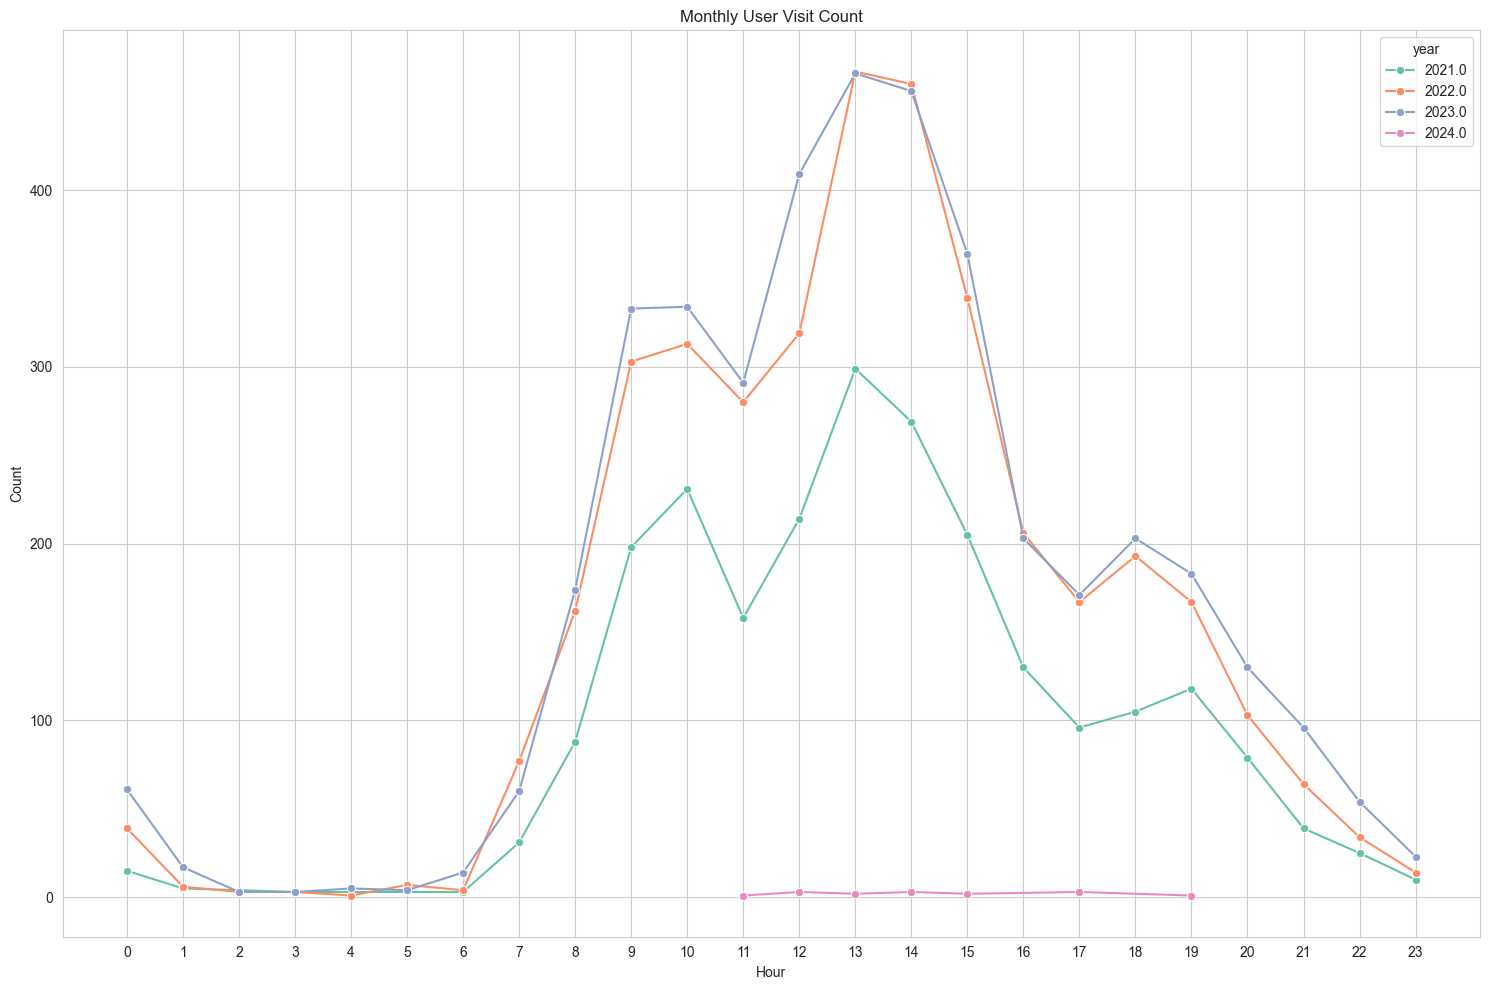

In [152]:
month_groupby_df = trial_visit_info_dropna.groupby(['year', 'hour']).size().reset_index(name='count')

plt.figure(figsize=(15, 10))
sns.set_style('whitegrid')
sns.lineplot(data=month_groupby_df, x='hour', y='count', hue='year', marker='o', palette='Set2')
plt.title('Monthly User Visit Count')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.xticks(month_groupby_df['hour'].unique())
plt.grid(True)
plt.tight_layout()
plt.show()

## 각 유저의 행동 로그 출력

In [153]:
trial_register['event_type'] = 'trial_register'
trial_visit_info['event_type'] = 'trial_visit_info'
trial_access_log['event_type'] = 'trial_access_log'
trial_payment['event_type'] = 'trial_payment'

In [154]:
concat_df = pd.concat([
    trial_register[['user_uuid', 'event_type', 'trial_date']],
    trial_visit_info[['user_uuid','event_type', 'first_enter_time']],
    trial_visit_info[['user_uuid','event_type', 'last_leave_time']],
    trial_access_log[['user_uuid','event_type', 'cdate', 'checkin']]],
                      axis=0, ignore_index=True)

In [155]:
for col in ['trial_date', 'first_enter_time', 'last_leave_time', 'cdate']:
	concat_df[col] = pd.to_datetime(concat_df[col], errors='coerce')
	
	if col in ['trial_date', 'cdate']:
		concat_df[col] += pd.Timedelta(hours=9)

concat_df

,user_uuid,event_type,trial_date,first_enter_time,last_leave_time,cdate,checkin
0,2b251333-8676-4c11-a736-dcf2350f8821,trial_register,2023-12-21 09:00:00,NaT,NaT,NaT,NaN
1,e111619a-0975-451b-9a4a-bc8aea7b7b84,trial_register,2023-12-21 09:00:00,NaT,NaT,NaT,NaN
2,4a184795-b056-4572-a874-644f68609ea3,trial_register,2023-12-21 09:00:00,NaT,NaT,NaT,NaN
3,2ba8ab19-2d40-4423-ad04-f0f9ca814871,trial_register,2023-12-21 09:00:00,NaT,NaT,NaT,NaN
4,1d49ba36-6c23-405b-9514-aa7f4aeceff0,trial_register,2023-12-21 09:00:00,NaT,NaT,NaT,NaN
...,...,...,...,...,...,...,...
96281,8b271f57-2ce2-4b32-80b8-0fabb98390a7,trial_access_log,NaT,NaT,NaT,2023-04-26 18:04:44.770319,2.0
96282,8b271f57-2ce2-4b32-80b8-0fabb98390a7,trial_access_log,NaT,NaT,NaT,2023-04-26 15:09:14.228682,1.0
96283,c02b96c8-bcba-4f8c-baf8-99f6c35076f4,trial_access_log,NaT,NaT,NaT,2023-11-04 20:50:10.657353,1.0
96284,c02b96c8-bcba-4f8c-baf8-99f6c35076f4,trial_access_log,NaT,NaT,NaT,2023-11-04 22:31:41.599473,2.0


In [137]:
concat_df['merged_datetime'] = concat_df[['trial_date', 'first_enter_time', 'last_leave_time', 'cdate']].bfill(axis=1).iloc[:, 0]

In [138]:
concat_df.drop(labels=['trial_date', 'first_enter_time', 'last_leave_time', 'cdate'], axis=1, inplace=True)

In [139]:
concat_df

,user_uuid,event_type,checkin,merged_datetime
0,2b251333-8676-4c11-a736-dcf2350f8821,trial_register,NaN,2023-12-21 18:00:00.000000
1,e111619a-0975-451b-9a4a-bc8aea7b7b84,trial_register,NaN,2023-12-21 18:00:00.000000
2,4a184795-b056-4572-a874-644f68609ea3,trial_register,NaN,2023-12-21 18:00:00.000000
3,2ba8ab19-2d40-4423-ad04-f0f9ca814871,trial_register,NaN,2023-12-21 18:00:00.000000
4,1d49ba36-6c23-405b-9514-aa7f4aeceff0,trial_register,NaN,2023-12-21 18:00:00.000000
...,...,...,...,...
96281,8b271f57-2ce2-4b32-80b8-0fabb98390a7,trial_access_log,2.0,2023-04-26 18:04:44.770319
96282,8b271f57-2ce2-4b32-80b8-0fabb98390a7,trial_access_log,1.0,2023-04-26 15:09:14.228682
96283,c02b96c8-bcba-4f8c-baf8-99f6c35076f4,trial_access_log,1.0,2023-11-04 20:50:10.657353
96284,c02b96c8-bcba-4f8c-baf8-99f6c35076f4,trial_access_log,2.0,2023-11-04 22:31:41.599473


In [140]:
concat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96286 entries, 0 to 96285
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_uuid        96286 non-null  object        
 1   event_type       96286 non-null  object        
 2   checkin          63708 non-null  float64       
 3   merged_datetime  93603 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 2.9+ MB


In [141]:
concat_groupby_df = concat_df.groupby(['user_uuid', 'merged_datetime'])[['event_type', 'checkin']].max().reset_index()

In [142]:
concat_groupby_df[concat_groupby_df['user_uuid'] == '000590dc-046f-462b-8225-4c81a97b7166']

,user_uuid,merged_datetime,event_type,checkin
0,000590dc-046f-462b-8225-4c81a97b7166,2023-09-04 18:00:00.000000,trial_register,NaN
1,000590dc-046f-462b-8225-4c81a97b7166,2023-09-05 11:57:01.148452,trial_visit_info,NaN
2,000590dc-046f-462b-8225-4c81a97b7166,2023-09-05 11:57:01.695334,trial_access_log,1.0
3,000590dc-046f-462b-8225-4c81a97b7166,2023-09-05 13:24:05.907486,trial_access_log,2.0
4,000590dc-046f-462b-8225-4c81a97b7166,2023-09-05 13:27:46.318391,trial_access_log,1.0
5,000590dc-046f-462b-8225-4c81a97b7166,2023-09-05 16:14:07.010936,trial_access_log,2.0
6,000590dc-046f-462b-8225-4c81a97b7166,2023-09-05 16:16:13.012870,trial_access_log,1.0
7,000590dc-046f-462b-8225-4c81a97b7166,2023-09-05 17:59:45.443621,trial_visit_info,NaN
8,000590dc-046f-462b-8225-4c81a97b7166,2023-09-05 17:59:45.973499,trial_access_log,2.0
